# Alternative Credit Scoring - Kenya Context

Build a credit score using alternative financial signals (mobile money, 
savings, employment) instead of traditional credit history, reaching the 
60% of Kenyans excluded from formal banking.


---

## Project Structure

- `src/data.py` - Data loading
- `src/features.py` - Feature engineering (17 features)
- `src/models.py` - Model training & comparison (5 classifiers)
- `src/scoring.py` - Credit scoring (0-100) + reason codes
- `src/evaluation.py` - Fairness checks

## Phase 1: Load the Raw Data

In [3]:
# Phase 1: Load the raw German Credit Data (csv file)
from src.data import load_data

df = load_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# Check for missing values in the raw data
from src.data import missing_value_summary

missing_value_summary(df)

,missing_count,missing_pct
Saving accounts,183,18.3
Checking account,394,39.4


## Phase 2: Engineer Features

In [5]:
# Phase 2: Transform raw data into 17 engineered features
# Features are reframed as Kenya alternative-data signals:
# - Savings account → M-Shwari like engagement
# - Checking account → M-Pesa like activity
# - Job → Income stability
# - Housing → Housing tenure
# - Purpose → Loan reason

from src.features import engineer_features

features_df = engineer_features(df)
print(f"Shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")
features_df.head()

Shape: (1000, 18)
Columns: ['loan_default', 'age', 'job_level', 'credit_amount', 'duration', 'has_savings_account', 'savings_level', 'has_mobile_money_account', 'mobile_money_level', 'housing_own', 'housing_rent', 'purpose_car', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_radio/TV', 'purpose_repairs', 'purpose_vacation/others']


,loan_default,age,job_level,credit_amount,duration,has_savings_account,savings_level,has_mobile_money_account,mobile_money_level,housing_own,housing_rent,purpose_car,purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_radio/TV,purpose_repairs,purpose_vacation/others
0,0,67,2,1169,6,0,0,1,1,1,0,0,0,0,0,1,0,0
1,1,22,2,5951,48,1,1,1,2,1,0,0,0,0,0,1,0,0
2,0,49,1,2096,12,1,1,0,0,1,0,0,0,1,0,0,0,0
3,0,45,2,7882,42,1,1,1,1,0,0,0,0,0,1,0,0,0
4,1,53,2,4870,24,1,1,1,1,0,0,1,0,0,0,0,0,0


## Phase 3: Train and Compare Models

In [23]:
# Split data into train/test sets and scale features
from src.models import split_data, compare_models, get_best_model

X_train, X_test, y_train, y_test = split_data(features_df)

print(f"Train: {X_train.shape[0]} customers ({y_train.mean():.1%} default rate)")
print(f"Test:  {X_test.shape[0]} customers ({y_test.mean():.1%} default rate)")
print()

# Train 5 different classifiers and compare their performance
results_df, scaler = compare_models(X_train, X_test, y_train, y_test)
results_df[['Model', 'Accuracy', 'AUC', 'CV_AUC']]

Train: 800 customers (30.0% default rate)
Test:  200 customers (30.0% default rate)



,Model,Accuracy,AUC,CV_AUC
0,Logistic Regression,0.735,0.757262,0.751860
1,Random Forest,0.765,0.758810,0.724163
2,Gradient Boosting,0.770,0.779643,0.742188
3,Decision Tree,0.710,0.704345,0.646949
4,Support Vector Machine,0.750,0.738095,0.729948


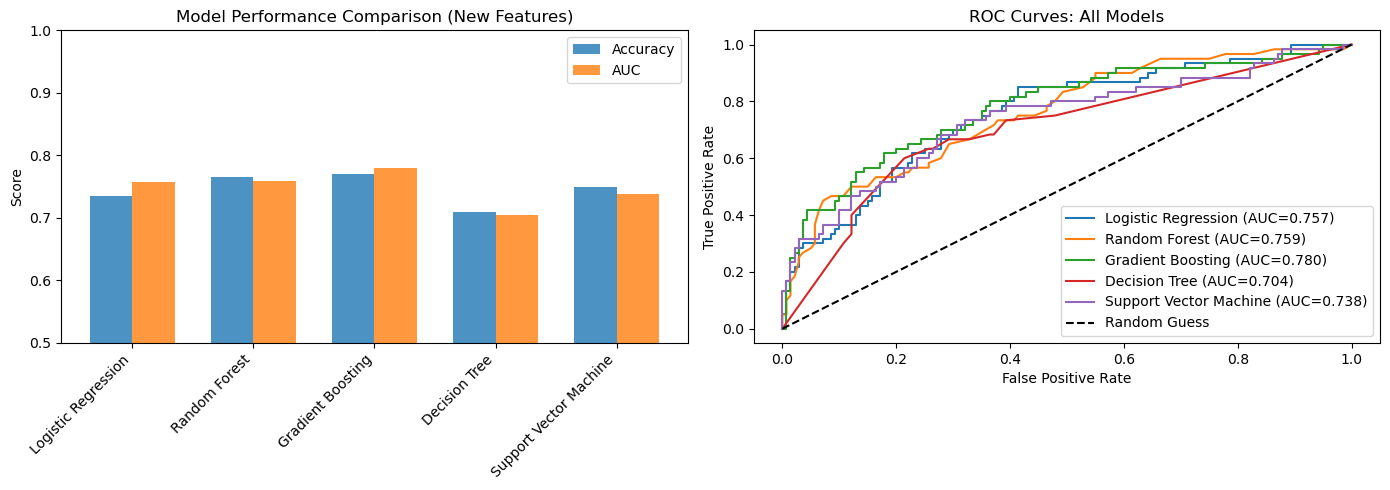

In [7]:
# Visualize model performance: comparison bar chart and ROC curves for all models

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Compare Accuracy vs AUC across models
models = results_df['Model'].values
acc = results_df['Accuracy'].values
auc_scores = results_df['AUC'].values

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, acc, width, label='Accuracy', alpha=0.8)
axes[0].bar(x + width/2, auc_scores, width, label='AUC', alpha=0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison (New Features)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim([0.5, 1.0])

# Right: ROC curves for all models
for idx, row in results_df.iterrows():
    fpr, tpr, _ = roc_curve(y_test, row['Probabilities'])
    auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"{row['Model']} (AUC={auc_val:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves: All Models')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

Best Model: Gradient Boosting
AUC Score: 0.780


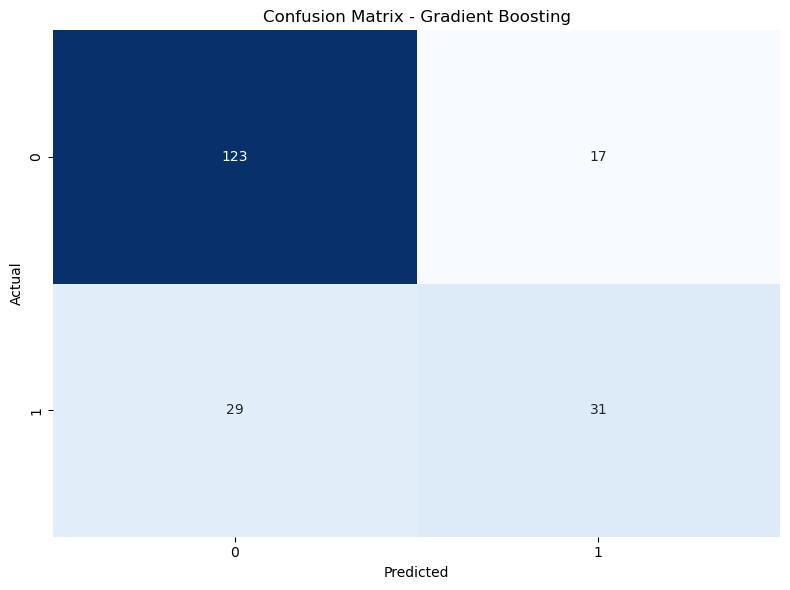

In [10]:
# Identify the best-performing model
best_idx = results_df['AUC'].idxmax()
best_model = results_df.loc[best_idx]

print(f"Best Model: {best_model['Model']}")
print(f"AUC Score: {best_model['AUC']:.3f}")

# Confusion Matrix: How many correct/incorrect predictions for the best model?
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_predictions = best_model['Predictions']
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_model["Model"]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

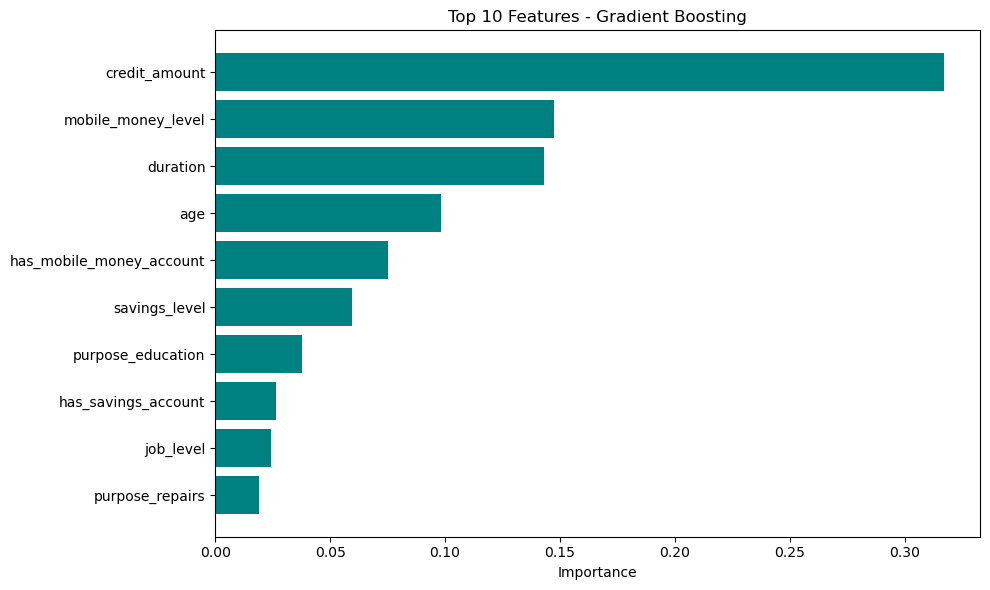

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
# Feature Importance: Which features matter most for credit decisions?
best_model_obj = best_model['Object']
if hasattr(best_model_obj, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model_obj.feature_importances_
    }).sort_values('importance', ascending=True).tail(10)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model["Model"]}')
    plt.tight_layout()
    plt.show()
else:
    print("Model does not support feature importance")

## Phase 4: Credit Scoring


In [13]:
# Phase 4: Score two real customers from the test set
# 1. Lowest-risk: Customer the model is most confident will repay
# 2. Highest-risk: Customer the model is most confident will default
# 
# For each, show: credit score (0-100), risk tier, and top 3 reasons why

import pandas as pd
from src.scoring import score_customer, explain_score

best_model_obj = best_model['Object']
y_prob_best = best_model_obj.predict_proba(X_test)[:, 1]
probs = pd.Series(y_prob_best, index=X_test.index)

low_risk_idx = probs[y_test == 0].idxmin()
high_risk_idx = probs[y_test == 1].idxmax()

for label, idx in [("Lowest-risk customer", low_risk_idx), ("Highest-risk customer", high_risk_idx)]:
    row = X_test.loc[[idx]]
    result = score_customer(best_model_obj, row)
    print(f"--- {label} (test set index {idx}) ---")
    for key, value in result.items():
        print(f"{key}: {value}")
    print("\nTop reasons:")
    print(explain_score(best_model_obj, row, X_train, y_train).to_string(index=False))
    print()

--- Lowest-risk customer (test set index 725) ---
credit_score: 98.6
risk_level: EXCELLENT
default_probability: 1.4
recommendation: Approve at standard terms
interest_rate_adjustment: -1% (preferred rate)

Top reasons:
      feature  applicant_value  typical_repaid  typical_defaulted    impact
credit_amount              250         2946.85            3755.99 -0.348438
     duration                6           19.18              24.49 -0.178701
savings_level                4            1.24               1.15 -0.169650

--- Highest-risk customer (test set index 11) ---
credit_score: 11.9
risk_level: VERY POOR
default_probability: 88.1
recommendation: Decline
interest_rate_adjustment: Not available

Top reasons:
      feature  applicant_value  typical_repaid  typical_defaulted   impact
     duration               48           19.18              24.49 0.329453
credit_amount             4308         2946.85            3755.99 0.132568
          age               24           35.74          

## Phase 5: Fairness Evaluation

In [18]:

# Set up the best model's predictions for fairness checks
# Check: Does the model treat different groups (Sex, Mobile Money Account) fairly?

from src.evaluation import fairness_report

best_idx = results_df['AUC'].idxmax()
best_model = results_df.loc[best_idx]

y_pred = best_model['Predictions']
y_prob = best_model['Probabilities']

print(f"Best Model: {best_model['Model']}")
print(f"AUC: {best_model['AUC']:.3f}")

Best Model: Gradient Boosting
AUC: 0.780


In [21]:
# Check fairness across Sex groups
# Does the model treat male and female applicants similarly?
# If no discrimination found, the model is fair on this dimension

sex_test = df.loc[y_test.index, 'Sex']

print("Group sizes (Sex):")
print(sex_test.value_counts())
print()

fairness_report(y_test, y_pred, y_prob, sex_test)

Group sizes (Sex):
Sex
male      139
female     61
Name: count, dtype: int64



,group,n,actual_default_rate,approval_rate,auc,false_positive_rate,false_negative_rate
0,female,61,0.327869,0.704918,0.815854,0.121951,0.35
1,male,139,0.287770,0.784173,0.762374,0.121212,0.55


In [22]:
# Check fairness across Mobile Money Account groups
# Does the model treat "unbanked" (no account) vs "banked" (has account) fairly?
# Metrics: approval rate, false positive rate (wrongly denied), false negative rate (wrongly approved)

print("Group sizes (has_mobile_money_account):")
print(X_test['has_mobile_money_account'].value_counts())
print()

fairness_report(y_test, y_pred, y_prob, X_test['has_mobile_money_account'])

Group sizes (has_mobile_money_account):
has_mobile_money_account
1    122
0     78
Name: count, dtype: int64



,group,n,actual_default_rate,approval_rate,auc,false_positive_rate,false_negative_rate
0,0,78,0.102564,0.974359,0.532143,0.014286,0.875000
1,1,122,0.426230,0.622951,0.730220,0.228571,0.423077
